<a href="https://colab.research.google.com/github/reddolivia/ds-learning/blob/main/intro_leNet_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [5]:
# Downloading the data
mnist  = tf.keras.datasets.mnist
(xtrain, ytrain), (xtest, ytest) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
xtrain[9].shape

(28, 28)

In [8]:
# finding the dimenstions
print(xtrain.shape)
print(xtest.shape)

(60000, 28, 28)
(10000, 28, 28)


As we can see, each image has dimensions 28x28.

Next, we divide the training and testing data by 255 to normalize them.

In [9]:
# performing the normalization
xtrain = xtrain / 255
xtest  = xtest / 255

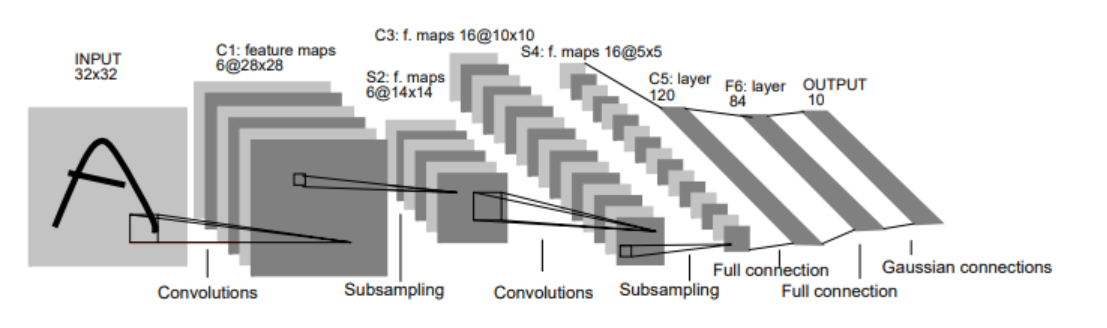

In [16]:
model  = tf.keras.Sequential()
# Layers C1-2: input -> Conv2d -> pooling
model.add(tf.keras.Input((28,28,1)))

# conv layer 6filters 5x5 activation -> 'tanh' & 'same'
model.add(tf.keras.layers.Conv2D(filters = 6, kernel_size = (5,5), activation = 'tanh', padding = 'same'))

# pooling layer
model.add(tf.keras.layers.AveragePooling2D(pool_size = (2,2), strides=(2, 2)))




# Layers C2-S4: Conv2D -> fully connected -> fully connected
model.add(tf.keras.layers.Conv2D(filters = 16, kernel_size = (5,5), activation = 'tanh', padding = 'valid'))
model.add(tf.keras.layers.AveragePooling2D(pool_size = (2,2), strides=(2, 2)))


# Layers F5-F6-F7: fully connected -> fully connected
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(units = 120, activation = 'sigmoid'))
model.add(tf.keras.layers.Dense(84, activation = 'sigmoid'))
model.add(tf.keras.layers.Dense(10, activation = 'softmax'))


In [21]:
# COMPILE & EVALUATION
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    xtrain,
    ytrain,
    batch_size=32,
    epochs=20,
    validation_split=0.1
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - accuracy: 0.9030 - loss: 0.3660 - val_accuracy: 0.9730 - val_loss: 0.0945
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.9733 - loss: 0.0889 - val_accuracy: 0.9797 - val_loss: 0.0684
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.9823 - loss: 0.0584 - val_accuracy: 0.9827 - val_loss: 0.0528
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.9866 - loss: 0.0448 - val_accuracy: 0.9868 - val_loss: 0.0468
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 43s 22ms/step - accuracy: 0.9892 - loss: 0.0361 - val_accuracy: 0.9877 - val_loss: 0.0411
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.9912 - loss: 0.0298 - val_accuracy: 0.9873 - val_loss: 0.0434
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.9918 - loss: 0.0252 - val_accuracy: 0.9875 - val_loss: 0.0423
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.9934 -

In [22]:
# CHECKING THE NO OF PARAMETERS
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,120 (723.13 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 123,414 (482.09 KB)

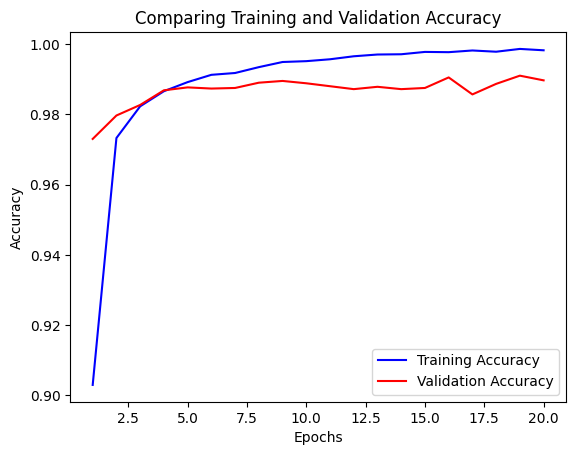

In [23]:
# --------------extract model acc-------------------

ta     = history.history['accuracy']
va     = history.history['val_accuracy']
epochs = range(1,21)

# plotting the accuracy
plt.figure()
plt.plot(epochs, ta,'b', label = 'Training Accuracy')
plt.plot(epochs, va, 'r',label = "Validation Accuracy")
plt.title("Comparing Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


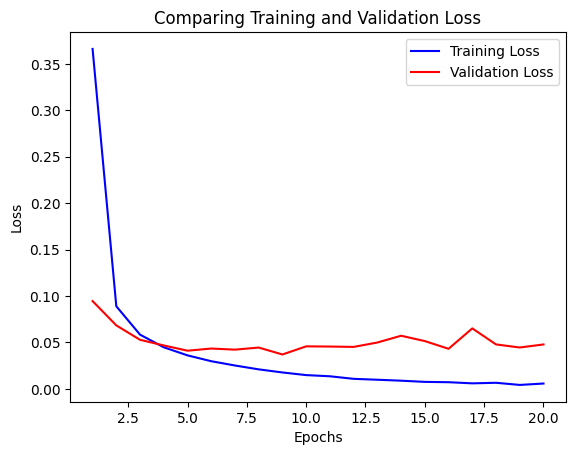

In [24]:
# ----------------ectracting the model loss--------------

tl  = history.history['loss']
vl  = history.history['val_loss']
epochs = range(1,21)

plt.figure()
plt.plot(epochs, tl, 'b', label = 'Training Loss')
plt.plot(epochs, vl, 'r', label = 'Validation Loss')
plt.title("Comparing Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

As we can see, there training loss decreases and then plateaus, whereas the validation loss is more or less constant. There is not much difference between the training and validation losses.

To evaluate the performance of the model on the test set, we use the evaluate() function and print the model's accuracy on the testing set.

In [26]:
# --------------EVALUATING MODEL----------------

print(str.format("Accuracy on Test Set: {:.2f}%", model.evaluate(xtest, ytest)[1]*100))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9897 - loss: 0.0361
Accuracy on Test Set: 98.97%


In [27]:
# obtaining the predictions

pred = np.argmax(model.predict(xtest), axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [28]:
# printing the classification report
from sklearn.metrics import classification_report
print(classification_report(ytest, pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



As we can see, the metrics range between 0.97-1.00, which means that the model performs very well.

Now, we plot a confusion matrix using the confusion_matrix() function from the sklearn library and the heatmap() function from the Seaborn library.

Text(50.722222222222214, 0.5, 'Actual')

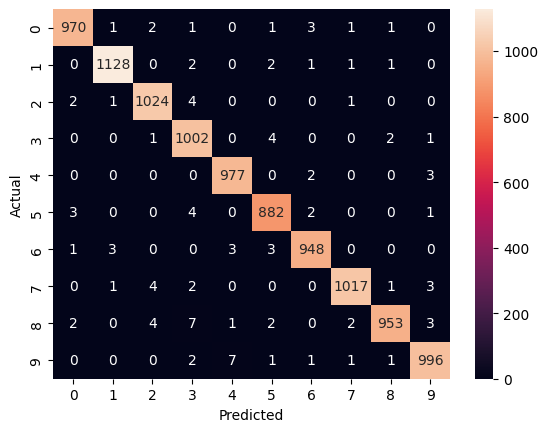

In [32]:
# plotting the confusion matrix
from sklearn.metrics import confusion_matrix


sns.heatmap(confusion_matrix(ytest, pred), annot = True, fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('Actual')